RAG

In [2]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage
from typing import TypedDict, Annotated, List
from langchain_core.documents import Document

c:\Users\ASUS\.conda\envs\graph-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

Process the pdf

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader


In [5]:
loader = PyPDFLoader("attention.pdf")
chunks = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 100)
docs = text_splitter.split_documents(chunks)

In [6]:
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

In [7]:
embeddings = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13956\2131500445.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


In [8]:
db = FAISS.from_documents(docs, embeddings)

In [11]:
retriever = db.as_retriever(k=5)

Graph WorkFlow

In [17]:
class RAGState(TypedDict):
    question: str
    documents: List[Document]
    answer: str
    chat_history: List[BaseMessage]

In [18]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Use the provided context to answer."),
    ("system", "Context:\n{context}"),
    ("placeholder", "{chat_history}"),
    ("human", "{question}")
])

In [19]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant")

In [20]:
#node
def retrieve(state: RAGState):
    docs = retriever.invoke(state["question"])
    return {"documents": docs}

In [ ]:
def generate(state: RAGState):
    context = "\n\n".join(doc.page_content for doc in state["documents"])

    messages = prompt.format_messages(
        context=context,
        question=state["question"],
        chat_history=state.get("chat_history", [])
    )

    response = llm.invoke(messages)

    return {
        "answer": response.content,
        "chat_history": state.get("chat_history", []) + [
            HumanMessage(content=state["question"]),
            response
        ]
    }

GRAPH WORKFLOW

In [22]:
graph = StateGraph(RAGState)

graph.add_node("retrieve", retrieve)
graph.add_node("generate", generate)

graph.set_entry_point("retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)

In [23]:
memory = MemorySaver()

In [24]:
app = graph.compile(checkpointer=memory)

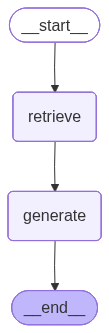

In [25]:
app

Inference

In [26]:
config = {"configurable": {"thread_id": "rag-chat-1"}}

In [28]:
print("Type 'exit' or 'quit' to stop.\n")

while True:
    query = input("You: ")

    if query.lower() in ["exit", "quit"]:
        print("👋 Bye!")
        break

    result = app.invoke(
        {
            "question": query,
        },
    config=config
    )
    print("Bot:", result["answer"])


Type 'exit' or 'quit' to stop.

Bot: As I mentioned earlier, attention is a fundamental concept in deep learning, particularly in natural language processing (NLP) and computer vision. It's a mechanism that allows a model to selectively focus on specific parts of the input data that are relevant to a particular task or decision.

Here's a simple analogy to help understand attention:

**Imagine you're at a party and you want to focus on a specific conversation with a friend.**

In a crowded room, it's easy to get distracted by multiple conversations and background noise. But, if you focus your attention on the conversation with your friend, you can ignore the other conversations and noise, and engage more deeply with your friend.

**Attention is like the spotlight that shines on the conversation with your friend.**

It helps you filter out irrelevant information, weight the importance of different elements, and capture long-range dependencies.

In deep learning, attention is used to ach